# Phase 1 Kaggle Ablation - Qwen 0.5B SFT

This notebook is the Kaggle-safe ablation runner for the next step after the 1000-step canary. It uses the production CLI, but keeps the model download, YAML generation, checkpoint lookup, and test-loss evaluation visible.

Recommended order:

1. Run the current 1000-step GSM8K-only canary.
2. Run this three-arm SFT ablation: GSM8K-only, MATH-only, combined GSM8K+MATH.
3. Compare GSM8K and MATH test loss for each arm.
4. Add generation exact-answer evaluation after the loss-only picture is stable.

DPO is intentionally not in this notebook. DPO needs a preference dataset or preference-generation pipeline; this notebook answers whether the SFT data mixture is worth scaling first.

## Step 1 - GPU and runtime check

Use Kaggle GPU, preferably T4. Do not use P100 if PyTorch warns that sm_60 is unsupported.

In [1]:
!nvidia-smi

Mon May 11 00:16:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import subprocess
import sys
from pathlib import Path

try:
    import torch
    print('torch:', torch.__version__)
    print('cuda available:', torch.cuda.is_available())
    print('device count:', torch.cuda.device_count())
    if torch.cuda.is_available():
        for idx in range(torch.cuda.device_count()):
            print(idx, torch.cuda.get_device_name(idx), torch.cuda.get_device_capability(idx))
except Exception as exc:
    print('torch check failed:', repr(exc))

torch: 2.10.0+cu128
cuda available: True
device count: 2
0 Tesla T4 (7, 5)
1 Tesla T4 (7, 5)


## Step 2 - Repo setup and import path

The CLI runs in a new Python process, so it needs `PYTHONPATH=/kaggle/working/finpost/src`, not just notebook `sys.path`.

In [3]:
REPO_DIR = Path('/kaggle/working/finpost')
SRC_DIR = REPO_DIR / 'src'

%cd /kaggle/working
!test -d finpost || git clone https://github.com/shannan-liu1/finpost.git
%cd /kaggle/working/finpost
!pip install -q -e .

os.environ['PYTHONPATH'] = str(SRC_DIR)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

for name in list(sys.modules):
    if name == 'finpost' or name.startswith('finpost.'):
        del sys.modules[name]

import finpost
print('finpost loaded from:', finpost.__file__)

/kaggle/working
/kaggle/working/finpost
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Installing backend dependencies ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 13.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 95.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.8 MB/s eta 0:00:00
  Building editable for finpost (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following 

## Step 3 - Settings

Defaults are conservative for Kaggle T4. If your 1000-step CLI canary is stable at `max_seq_len=1024`, you can raise `MAX_SEQ_LEN` back to 1024. For first ablations, `512` is safer and cheaper.

In [4]:
from datetime import datetime

MODEL_REPO_ID = 'Qwen/Qwen2.5-0.5B'
MODEL_DIR = Path('/kaggle/working/models/qwen2_5_0_5b')

ABLATION_STEPS = 1000
MAX_SEQ_LEN = 512
DTYPE = 'float32'
LR = 1.0e-5
PER_DEVICE_BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 4
WEIGHT_DECAY = 0.01
GRAD_CLIP = 1.0
VAL_SPLIT_PCT = 5.0
SEED = 42

# Start with one arm if you want a short smoke pass. Then run all three.
RUN_ARMS = ['gsm8k_only', 'math_only', 'combined']

# For quick eval during notebook iteration. Set to None for full test splits.
EVAL_MAX_EXAMPLES = 500

# Unique suffix prevents checkpoint collisions when rerunning the same arm.
RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')

ARMS = {
    'gsm8k_only': ['gsm8k'],
    'math_only': ['math'],
    'combined': ['gsm8k', 'math'],
}

print('arms:', RUN_ARMS)
print('steps:', ABLATION_STEPS)
print('max_seq_len:', MAX_SEQ_LEN)
print('effective batch:', PER_DEVICE_BATCH_SIZE * GRAD_ACCUM_STEPS)
print('run tag:', RUN_TAG)

arms: ['gsm8k_only', 'math_only', 'combined']
steps: 1000
max_seq_len: 512
effective batch: 4
run tag: 20260511_001656


## Step 4 - Optional Hugging Face token

Qwen does not require a token, but setting `HF_TOKEN` can reduce rate-limit noise. For gated models later, this becomes required.

In [5]:
HF_TOKEN = None
try:
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    HF_TOKEN = secrets.get_secret('HF_TOKEN')
except Exception as exc:
    print('No Kaggle HF_TOKEN secret loaded:', repr(exc))

if HF_TOKEN:
    from huggingface_hub import login
    os.environ['HF_TOKEN'] = HF_TOKEN
    login(token=HF_TOKEN)
    print('HF token loaded')
else:
    print('Proceeding without HF token')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF token loaded


## Step 5 - Download model once, then run locally

This avoids the partial `model.safetensors` download stalls that happen when `from_pretrained` fetches directly during model load.

In [12]:
!pip -q install hf_transfer
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = '1'

from huggingface_hub import snapshot_download

snapshot_download(
    repo_id=MODEL_REPO_ID,
    local_dir=str(MODEL_DIR),
    token=HF_TOKEN,
    allow_patterns=[
        '*.json',
        '*.safetensors',
        'tokenizer.*',
        'vocab.json',
        'merges.txt',
    ],
)

required = ['config.json']
missing = [name for name in required if not (MODEL_DIR / name).exists()]
if missing:
    raise RuntimeError(f'Model download incomplete; missing {missing}')

print('model dir:', MODEL_DIR)
print('files:', sorted(p.name for p in MODEL_DIR.iterdir())[:20])

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

model dir: /kaggle/working/models/qwen2_5_0_5b
files: ['.cache', 'config.json', 'generation_config.json', 'merges.txt', 'model.safetensors', 'tokenizer.json', 'tokenizer_config.json', 'vocab.json']


## Step 6 - Choose the CLI GPU

If Kaggle gives two T4s, this picks the GPU with the most free memory for the subprocess. The CLI still uses a single GPU.

In [13]:
def pick_cli_gpu() -> str:
    try:
        raw = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=memory.free', '--format=csv,noheader,nounits'],
            text=True,
        )
        free = [int(line.strip()) for line in raw.splitlines() if line.strip()]
        if not free:
            return '0'
        return str(max(range(len(free)), key=lambda idx: free[idx]))
    except Exception as exc:
        print('Could not query GPU memory:', repr(exc))
        return '0'

CLI_GPU = pick_cli_gpu()
print('CLI GPU index:', CLI_GPU)

CLI_ENV = os.environ.copy()
CLI_ENV['PYTHONPATH'] = str(SRC_DIR)
CLI_ENV['WANDB_MODE'] = 'offline'
CLI_ENV['CUDA_VISIBLE_DEVICES'] = CLI_GPU

subprocess.run(
    [sys.executable, '-c', 'import finpost; print(finpost.__file__)'],
    cwd=str(REPO_DIR),
    env=CLI_ENV,
    check=True,
)

CLI GPU index: 0
/kaggle/working/finpost/src/finpost/__init__.py


CompletedProcess(args=['/usr/bin/python3', '-c', 'import finpost; print(finpost.__file__)'], returncode=0)

## Step 7 - Write one YAML per ablation arm

The only intended difference across arms is the data mixture. Keep model, LR, batch, dtype, sequence length, seed, and training steps fixed. A timestamp run tag is included so reruns do not collide with old step directories.

In [14]:
import yaml

CONFIG_DIR = Path('/kaggle/working/phase1_ablation_configs')
SAVE_ROOT = Path('/kaggle/working/results/checkpoints/phase1_ablation')
CONFIG_DIR.mkdir(parents=True, exist_ok=True)
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

warmup_steps = max(1, min(ABLATION_STEPS // 10, ABLATION_STEPS - 1))
val_every = max(50, min(250, ABLATION_STEPS // 4))

def make_arm_config(arm_name: str, sources: list[str]) -> dict:
    run_name = f'qwen-ablate-{arm_name}-{ABLATION_STEPS}s-seq{MAX_SEQ_LEN}-{RUN_TAG}'
    return {
        'model': {
            'base_model_id': str(MODEL_DIR),
            'dtype': DTYPE,
            'use_safetensors': True,
        },
        'data': {
            'sources': sources,
            'val_split_pct': VAL_SPLIT_PCT,
            'seed': SEED,
        },
        'training': {
            'max_steps': ABLATION_STEPS,
            'warmup_steps': warmup_steps,
            'lr': LR,
            'weight_decay': WEIGHT_DECAY,
            'grad_accum_steps': GRAD_ACCUM_STEPS,
            'grad_clip': GRAD_CLIP,
            'val_every_n_steps': val_every,
            'checkpoint_every_n_steps': 999999,#ABLATION_STEPS,
            'per_device_batch_size': PER_DEVICE_BATCH_SIZE,
        },
        'packing': {
            'max_seq_len': MAX_SEQ_LEN,
            'isolate_documents': True,
        },
        'logging': {
            'wandb_project': 'finpost-phase1',
            'run_name': run_name,
        },
        'checkpointing': {
            'save_dir': str(SAVE_ROOT / run_name),
            'retention_last_n': 1,
            'resume_from': None,
        },
    }

ARM_CONFIGS = {}
for arm_name, sources in ARMS.items():
    cfg = make_arm_config(arm_name, sources)
    path = CONFIG_DIR / f'{arm_name}.yaml'
    with path.open('w', encoding='utf-8') as fp:
        yaml.safe_dump(cfg, fp, sort_keys=False)
    ARM_CONFIGS[arm_name] = {'path': path, 'config': cfg}
    print(arm_name, '->', path)
    print('  sources:', sources)
    print('  save_dir:', cfg['checkpointing']['save_dir'])

gsm8k_only -> /kaggle/working/phase1_ablation_configs/gsm8k_only.yaml
  sources: ['gsm8k']
  save_dir: /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656
math_only -> /kaggle/working/phase1_ablation_configs/math_only.yaml
  sources: ['math']
  save_dir: /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-math_only-1000s-seq512-20260511_001656
combined -> /kaggle/working/phase1_ablation_configs/combined.yaml
  sources: ['gsm8k', 'math']
  save_dir: /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-combined-1000s-seq512-20260511_001656


## Step 8 - Clear notebook GPU memory before CLI runs

This notebook should not have a model on GPU before the CLI starts. If `nvidia-smi` still shows several GB for the notebook process, restart the kernel and run only setup cells plus the CLI cells.

In [15]:
import gc

for name in ['model', 'optimizer', 'scheduler', 'out', 'outputs', 'loss', 'batch']:
    if name in globals():
        del globals()[name]

gc.collect()
if 'torch' in globals() and torch.cuda.is_available():
    torch.cuda.empty_cache()

!nvidia-smi

Mon May 11 00:32:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 9 - Run the ablation arms

This can take a while. For a smoke pass, set `RUN_ARMS = ['gsm8k_only']` in Step 3 and rerun from there.

In [16]:
%%writefile /kaggle/working/finpost/src/finpost/training/train_weights_only.py
from __future__ import annotations

import argparse
from pathlib import Path

import torch

from finpost.training.config import Config
from finpost.training.train import print_effective_config, resolve_config
from finpost.training.trainer import Trainer


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument("--config", type=Path, required=True)
    parser.add_argument("--device", type=str, default="cuda")
    parser.add_argument("--max-steps", type=int, default=None)
    args = parser.parse_args()

    config = resolve_config(
        config_path=args.config,
        max_steps_override=args.max_steps,
        resume_from_override=None,
    )
    print_effective_config(config)

    trainer = Trainer(config)
    trainer.device = torch.device(args.device)
    trainer._setup()
    trainer._run_training_loop()

    assert trainer.model is not None
    assert trainer.tokenizer is not None

    save_dir = Path(config.checkpointing.save_dir) / f"hf-step-{trainer.global_step:08d}"
    save_dir.mkdir(parents=True, exist_ok=True)
    trainer.model.save_pretrained(save_dir, safe_serialization=True)
    trainer.tokenizer.save_pretrained(save_dir)

    print("Saved weights-only checkpoint:", save_dir)


if __name__ == "__main__":
    main()


Overwriting /kaggle/working/finpost/src/finpost/training/train_weights_only.py


In [17]:
def run_arm(arm_name: str) -> None:
    info = ARM_CONFIGS[arm_name]
    cfg_path = info["path"]
    print(f"\n=== Running {arm_name} ===")
    print("config:", cfg_path)

    cmd = [
        sys.executable,
        "-m",
        "finpost.training.train_weights_only",
        "--config",
        str(cfg_path),
        "--device",
        "cuda",
        "--max-steps",
        str(ABLATION_STEPS),
    ]

    subprocess.run(cmd, cwd=str(REPO_DIR), env=CLI_ENV, check=True)

for arm_name in RUN_ARMS:
    if arm_name not in ARMS:
        raise ValueError(f"Unknown arm: {arm_name}")
    run_arm(arm_name)



=== Running gsm8k_only ===
config: /kaggle/working/phase1_ablation_configs/gsm8k_only.yaml
Effective config:
  model:                  /kaggle/working/models/qwen2_5_0_5b
  dtype:                  float32
  data sources:           ['gsm8k']
  max_steps:              1000
  warmup_steps:           100
  lr:                     1e-05
  per_device_batch_size:  1
  grad_accum_steps:       4
  effective batch size:   4
  max_seq_len:            512
  save_dir:               /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656
  resume_from:            None
  run_name:               qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656
  steps per epoch:        len(train_dataset) / 4 (computed once Trainer loads the dataset)


2026-05-11 00:32:51.357537: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778459571.577673     750 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778459571.646441     750 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778459572.179409     750 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778459572.179451     750 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778459572.179454     750 computation_placer.cc:177] computation placer alr

wandb: 
wandb: You can sync this run to the cloud by running:
wandb: wandb sync /kaggle/working/finpost/wandb/offline-run-20260511_003318-ksf3k68u
wandb: Find logs at: wandb/offline-run-20260511_003318-ksf3k68u/logs
Saved weights-only checkpoint: /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656/hf-step-00001000

=== Running math_only ===
config: /kaggle/working/phase1_ablation_configs/math_only.yaml
Effective config:
  model:                  /kaggle/working/models/qwen2_5_0_5b
  dtype:                  float32
  data sources:           ['math']
  max_steps:              1000
  warmup_steps:           100
  lr:                     1e-05
  per_device_batch_size:  1
  grad_accum_steps:       4
  effective batch size:   4
  max_seq_len:            512
  save_dir:               /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-math_only-1000s-seq512-20260511_001656
  resume_from:            None
  run_name:               

2026-05-11 00:55:00.457093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778460900.476840     831 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778460900.482874     831 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778460900.505016     831 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778460900.505047     831 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778460900.505049     831 computation_placer.cc:177] computation placer alr

wandb: 
wandb: You can sync this run to the cloud by running:
wandb: wandb sync /kaggle/working/finpost/wandb/offline-run-20260511_005511-2z1cvvnl
wandb: Find logs at: wandb/offline-run-20260511_005511-2z1cvvnl/logs
[load_math] Skipped 2/7500 records (0.03%): {'parse_failure': 0, 'empty_answer': 2, 'difficulty_failure': 0, 'validation_failure': 0}
[load_math] Skipped 2/7500 records (0.03%): {'parse_failure': 0, 'empty_answer': 2, 'difficulty_failure': 0, 'validation_failure': 0}
Saved weights-only checkpoint: /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-math_only-1000s-seq512-20260511_001656/hf-step-00001000

=== Running combined ===
config: /kaggle/working/phase1_ablation_configs/combined.yaml
Effective config:
  model:                  /kaggle/working/models/qwen2_5_0_5b
  dtype:                  float32
  data sources:           ['gsm8k', 'math']
  max_steps:              1000
  warmup_steps:           100
  lr:                     1e-05
  per_device_batch_size:  

2026-05-11 01:22:52.212169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778462572.231460     927 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778462572.237699     927 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778462572.256989     927 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778462572.257024     927 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778462572.257027     927 computation_placer.cc:177] computation placer alr

wandb: 
wandb: You can sync this run to the cloud by running:
wandb: wandb sync /kaggle/working/finpost/wandb/offline-run-20260511_012303-34cvy4pd
wandb: Find logs at: wandb/offline-run-20260511_012303-34cvy4pd/logs
[load_math] Skipped 2/7500 records (0.03%): {'parse_failure': 0, 'empty_answer': 2, 'difficulty_failure': 0, 'validation_failure': 0}
[load_math] Skipped 2/7500 records (0.03%): {'parse_failure': 0, 'empty_answer': 2, 'difficulty_failure': 0, 'validation_failure': 0}
Saved weights-only checkpoint: /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-combined-1000s-seq512-20260511_001656/hf-step-00001000


## Step 10 - Locate weights-only checkpoints

The Kaggle-safe runner saves Hugging Face-style folders named `hf-step-XXXXXXXX/`. These are reloadable with `from_pretrained(...)`, but they do not include optimizer state for exact training resume.

In [18]:
def latest_hf_checkpoint(save_dir: str | Path) -> Path:
    save_dir = Path(save_dir)
    candidates = sorted(
        [p for p in save_dir.glob("hf-step-*") if p.is_dir()],
        key=lambda p: int(p.name.split("-")[-1]),
    )
    if not candidates:
        raise FileNotFoundError(f"No hf-step-* checkpoints under {save_dir}")
    return candidates[-1]

CHECKPOINTS = {}

for arm_name, info in ARM_CONFIGS.items():
    save_dir = info["config"]["checkpointing"]["save_dir"]
    if Path(save_dir).exists():
        try:
            CHECKPOINTS[arm_name] = latest_hf_checkpoint(save_dir)
            print(arm_name, "->", CHECKPOINTS[arm_name])
        except FileNotFoundError as exc:
            print(arm_name, "missing:", exc)
    else:
        print(arm_name, "save_dir missing:", save_dir)


gsm8k_only -> /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656/hf-step-00001000
math_only -> /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-math_only-1000s-seq512-20260511_001656/hf-step-00001000
combined -> /kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-combined-1000s-seq512-20260511_001656/hf-step-00001000


## Step 11 - Loss-only test evaluation

This evaluates gold-response cross entropy on held-out test splits. It does not measure generated final-answer accuracy. Use it to compare arms cheaply and consistently.

In [19]:
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

from finpost.data.gsm8k import load_gsm8k
from finpost.data.math_dataset import load_math
from finpost.training.dataset import (
    PackingCollator,
    TokenizedSFTExample,
    serialize_prompt,
    serialize_response,
)
from finpost.training.masking import IGNORE_INDEX

class TestSFTDataset(Dataset):
    def __init__(self, examples, tokenizer):
        self.examples = examples
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        prompt_ids = self.tokenizer(serialize_prompt(ex.prompt), add_special_tokens=False)['input_ids']
        response_ids = self.tokenizer(serialize_response(ex.response), add_special_tokens=False)['input_ids']
        ids = torch.tensor(prompt_ids + response_ids, dtype=torch.long)
        return TokenizedSFTExample(
            input_ids=ids,
            prompt_length=len(prompt_ids),
            source=ex.source,
            example_id=ex.id,
        )

def load_test_examples(source: str):
    if source == 'gsm8k':
        examples = load_gsm8k(split='test')
    elif source == 'math':
        examples = load_math(split='test')
    else:
        raise ValueError(source)
    if EVAL_MAX_EXAMPLES is not None:
        examples = examples[:EVAL_MAX_EXAMPLES]
    return examples

def ce_sum_and_count(logits: torch.Tensor, labels: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = labels[..., 1:].contiguous()
    flat_logits = shift_logits.view(-1, shift_logits.size(-1))
    flat_labels = shift_labels.view(-1)
    valid = flat_labels != IGNORE_INDEX
    if valid.sum() == 0:
        return torch.tensor(0.0, device=logits.device), valid.sum()
    loss_sum = F.cross_entropy(flat_logits[valid], flat_labels[valid], reduction='sum')
    return loss_sum, valid.sum()

def load_model_from_weights_checkpoint(ckpt_dir: Path):
    tok = AutoTokenizer.from_pretrained(
        ckpt_dir,
        local_files_only=True,
    )
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    dtype = getattr(torch, DTYPE)

    mdl = AutoModelForCausalLM.from_pretrained(
        ckpt_dir,
        dtype=dtype,
        use_safetensors=True,
        local_files_only=True,
    ).to("cuda")

    mdl.eval()
    return mdl, tok


def evaluate_test_loss(ckpt_dir: Path, test_source: str) -> dict:
    model, tokenizer = load_model_from_weights_checkpoint(ckpt_dir)
    examples = load_test_examples(test_source)
    
    collator = PackingCollator(
        max_seq_len=MAX_SEQ_LEN,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id or tokenizer.eos_token_id,
        isolate_documents=True,
    )

    loader = DataLoader(
        TestSFTDataset(examples, tokenizer),
        batch_size=PER_DEVICE_BATCH_SIZE,
        shuffle=False,
        collate_fn=collator,
    )


    total_nll = 0.0
    total_tokens = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to('cuda')
            labels = batch['labels'].to('cuda')
            attention_mask = batch['attention_mask'].to('cuda').bool()
            position_ids = batch['position_ids'].to('cuda')
            out = model(input_ids=input_ids, attention_mask=attention_mask, position_ids=position_ids)
            loss_sum, count = ce_sum_and_count(out.logits, labels)
            total_nll += float(loss_sum.detach().float().item())
            total_tokens += int(count.item())

    avg_loss = total_nll / total_tokens if total_tokens else float('nan')
    del model
    gc.collect()
    torch.cuda.empty_cache()
    return {
        'checkpoint': str(ckpt_dir),
        'test_source': test_source,
        'examples': len(examples),
        'tokens': total_tokens,
        'loss': avg_loss,
        'perplexity': float(torch.exp(torch.tensor(avg_loss)).item()) if total_tokens else float('nan'),
    }

## Step 12 - Compare arms on GSM8K and MATH test loss

For the clean ablation, every completed arm is evaluated on both test sets. The useful table is row = training arm, columns = test source losses.

In [20]:
import pandas as pd

EVAL_SOURCES = ['gsm8k', 'math']
rows = []

for arm_name in RUN_ARMS:
    if arm_name not in CHECKPOINTS:
        print('Skipping missing checkpoint:', arm_name)
        continue
    for source in EVAL_SOURCES:
        print(f'Evaluating {arm_name} on {source} test')
        row = evaluate_test_loss(CHECKPOINTS[arm_name], source)
        row['arm'] = arm_name
        row['trained_on'] = '+'.join(ARMS[arm_name])
        rows.append(row)

results = pd.DataFrame(rows)
results = results[['arm', 'trained_on', 'test_source', 'examples', 'tokens', 'loss', 'perplexity', 'checkpoint']]
results_path = Path('/kaggle/working/phase1_ablation_test_loss.csv')
results.to_csv(results_path, index=False)
print('saved:', results_path)
results

Evaluating gsm8k_only on gsm8k test


The tokenizer you are loading from '/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656/hf-step-00001000' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
2026-05-11 01:50:25.228141: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778464225.258429      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778464225.272638      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registere

Evaluating gsm8k_only on math test


The tokenizer you are loading from '/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656/hf-step-00001000' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Evaluating math_only on gsm8k test


...

The tokenizer you are loading from '/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-combined-1000s-seq512-20260511_001656/hf-step-00001000' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Evaluating combined on math test


The tokenizer you are loading from '/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-combined-1000s-seq512-20260511_001656/hf-step-00001000' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


saved: /kaggle/working/phase1_ablation_test_loss.csv


,arm,trained_on,test_source,examples,tokens,loss,perplexity,checkpoint
0,gsm8k_only,gsm8k,gsm8k,500,61909,0.471196,1.601909,/kaggle/working/results/checkpoints/phase1_abl...
1,gsm8k_only,gsm8k,math,500,70493,1.048437,2.853187,/kaggle/working/results/checkpoints/phase1_abl...
2,math_only,math,gsm8k,500,61909,1.031273,2.804634,/kaggle/working/results/checkpoints/phase1_abl...
3,math_only,math,math,500,70493,0.730494,2.076105,/kaggle/working/results/checkpoints/phase1_abl...
4,combined,gsm8k+math,gsm8k,500,61909,0.489146,1.630923,/kaggle/working/results/checkpoints/phase1_abl...
5,combined,gsm8k+math,math,500,70493,0.753691,2.124828,/kaggle/working/results/checkpoints/phase1_abl...


## Step 13 - Plot the comparison

saved: /kaggle/working/phase1_ablation_test_loss.png


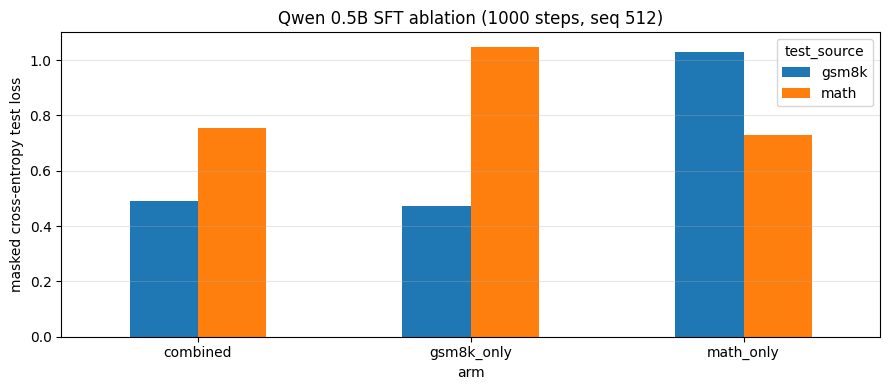

In [21]:
import matplotlib.pyplot as plt

if 'results' not in globals() or results.empty:
    raise RuntimeError('Run Step 12 first')

pivot = results.pivot(index='arm', columns='test_source', values='loss')
ax = pivot.plot(kind='bar', figsize=(9, 4), rot=0)
ax.set_ylabel('masked cross-entropy test loss')
ax.set_title(f'Qwen 0.5B SFT ablation ({ABLATION_STEPS} steps, seq {MAX_SEQ_LEN})')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plot_path = Path('/kaggle/working/phase1_ablation_test_loss.png')
plt.savefig(plot_path, dpi=160)
print('saved:', plot_path)
plt.show()

## Step 14 - Zip checkpoints and outputs for download

In [22]:
from IPython.display import FileLink, display
from pathlib import Path

for path in [
    "/kaggle/working/phase1_ablation_test_loss.csv",
    "/kaggle/working/phase1_ablation_test_loss.png",
]:
    p = Path(path)
    print(path, "exists:", p.exists(), "size MB:", round(p.stat().st_size / 1e6, 2) if p.exists() else None)
    if p.exists():
        display(FileLink(str(p)))


/kaggle/working/phase1_ablation_test_loss.csv exists: True size MB: 0.0


/kaggle/working/phase1_ablation_test_loss.csv

/kaggle/working/phase1_ablation_test_loss.png exists: True size MB: 0.05


/kaggle/working/phase1_ablation_test_loss.png

In [26]:
import shutil
from IPython.display import FileLink

#ckpt = "/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-combined-1000s-seq512-20260511_001656/hf-step-00001000"
#ckpt = "/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-math_only-1000s-seq512-20260511_001656/hf-step-00001000"
ckpt = "/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656/hf-step-00001000"


zip_path = shutil.make_archive(
    #"/kaggle/working/qwen_combined_hf_step_1000",
    "/kaggle/working/qwen_gsm8k_hf_step_1000",
    "zip",
    ckpt,
)

FileLink(zip_path)




/kaggle/working/qwen_gsm8k_hf_step_1000.zip

In [25]:
print('hi')

hi


In [ ]:
#import shutil
#from IPython.display import FileLink

#archive_base = '/kaggle/working/phase1_ablation_outputs'
#zip_path = shutil.make_archive(archive_base, 'zip', '/kaggle/working/results/checkpoints/phase1_ablation')
#print('checkpoint archive:', zip_path)
#FileLink(zip_path)

In [ ]:
from IPython.display import FileLink, display

for path in [
    '/kaggle/working/phase1_ablation_test_loss.csv',
    '/kaggle/working/phase1_ablation_test_loss.png',
]:
    if Path(path).exists():
        display(FileLink(path))
    else:
        print('missing:', path)

## Optional - exact-answer eval comes next

Loss-only eval is the right first comparison because it is stable and fast. The next layer is generation-based exact answer: prompt only, generate, parse the final answer, compare to `Example.final_answer`. Keep that separate because decoding settings can dominate the result.

In [27]:
import re, gc, torch
import pandas as pd
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from finpost.data.gsm8k import load_gsm8k, parse_gsm8k_final_answer
from finpost.data.math_dataset import load_math, parse_math_final_answer
from finpost.training.dataset import serialize_prompt

EVAL_N = 100          # start small; raise to 500/full later
MAX_NEW_TOKENS = 256 # raise for MATH if needed

def normalize_answer(x: str) -> str:
    return (
        str(x)
        .strip()
        .lower()
        .replace(",", "")
        .replace("$", "")
        .replace("\\left", "")
        .replace("\\right", "")
        .replace(" ", "")
    )

def extract_pred_answer(source: str, text: str) -> str | None:
    if source == "gsm8k":
        try:
            return parse_gsm8k_final_answer(text)
        except Exception:
            # fallback: last number in generated text
            nums = re.findall(r"-?\d+(?:\.\d+)?", text.replace(",", ""))
            return nums[-1] if nums else None

    if source == "math":
        try:
            return parse_math_final_answer(text)
        except Exception:
            # fallback: last boxed answer or last number
            boxed = re.findall(r"\\boxed\{([^{}]+)\}", text)
            if boxed:
                return boxed[-1]
            nums = re.findall(r"-?\d+(?:\.\d+)?", text.replace(",", ""))
            return nums[-1] if nums else None

    raise ValueError(source)

def load_eval_examples(source: str, n: int | None = EVAL_N):
    examples = load_gsm8k("test") if source == "gsm8k" else load_math("test")
    return examples if n is None else examples[:n]

def exact_answer_eval(ckpt_dir: str, source: str, n: int | None = EVAL_N):
    # load tokenizer from base model
    tokenizer = AutoTokenizer.from_pretrained(
        MODEL_DIR,  # /kaggle/working/models/qwen2_5_0_5b
        local_files_only=True,
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # load model from fine-tuned ckpt
    model = AutoModelForCausalLM.from_pretrained(
        ckpt_dir,
        dtype=torch.float32,
        use_safetensors=True,
        local_files_only=True,
    ).to("cuda")
    model.eval()

    examples = load_eval_examples(source, n)
    rows = []

    for ex in tqdm(examples, desc=f"{source} eval"):
        prompt = serialize_prompt(ex.prompt)
        enc = tokenizer(prompt, return_tensors="pt", add_special_tokens=False).to("cuda")

        with torch.no_grad():
            out = model.generate(
                **enc,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        gen_text = tokenizer.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=False)
        pred = extract_pred_answer(source, gen_text)
        gold = ex.final_answer

        correct = normalize_answer(pred) == normalize_answer(gold) if pred is not None else False

        rows.append({
            "id": ex.id,
            "source": source,
            "gold": gold,
            "pred": pred,
            "correct": correct,
            "generated": gen_text[:500],
        })

    df = pd.DataFrame(rows)
    acc = float(df["correct"].mean()) if len(df) else float("nan")

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return acc, df


In [28]:
checkpoint_paths = {
    "gsm8k_only": "/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656/hf-step-00001000",
    "math_only": "/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-math_only-1000s-seq512-20260511_001656/hf-step-00001000",
    "combined": "/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-combined-1000s-seq512-20260511_001656/hf-step-00001000",
}

acc_rows = []
detail_dfs = {}

for arm, ckpt in checkpoint_paths.items():
    for source in ["gsm8k", "math"]:
        acc, df = exact_answer_eval(ckpt, source, n=EVAL_N)
        acc_rows.append({"arm": arm, "test_source": source, "n": len(df), "accuracy": acc})
        detail_dfs[(arm, source)] = df
        print(arm, source, acc)

acc_results = pd.DataFrame(acc_rows)
acc_results


The tokenizer you are loading from '/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656/hf-step-00001000' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


gsm8k eval:   0%|          | 0/100 [00:00<?, ?it/s]

gsm8k_only gsm8k 0.08


The tokenizer you are loading from '/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-gsm8k_only-1000s-seq512-20260511_001656/hf-step-00001000' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


math eval:   0%|          | 0/100 [00:00<?, ?it/s]

...

combined gsm8k 0.14


The tokenizer you are loading from '/kaggle/working/results/checkpoints/phase1_ablation/qwen-ablate-combined-1000s-seq512-20260511_001656/hf-step-00001000' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


math eval:   0%|          | 0/100 [00:00<?, ?it/s]

combined math 0.16


,arm,test_source,n,accuracy
0,gsm8k_only,gsm8k,100,0.08
1,gsm8k_only,math,100,0.10
2,math_only,gsm8k,100,0.00
3,math_only,math,100,0.17
4,combined,gsm8k,100,0.14
5,combined,math,100,0.16


In [31]:
import os
import pandas as pd

OUT_DIR = "/kaggle/working/acc_eval"
os.makedirs(OUT_DIR, exist_ok=True)

# 1. Save summary accuracy table
summary_path = os.path.join(OUT_DIR, "accuracy_summary.csv")
acc_results.to_csv(summary_path, index=False)

# 2. Save per-arm/source detailed eval outputs
for (arm, source), df in detail_dfs.items():
    detail_path = os.path.join(OUT_DIR, f"details_{arm}_{source}.csv")
    df.to_csv(detail_path, index=False)

print(f"Saved summary to: {summary_path}")
print(f"Saved detail CSVs to: {OUT_DIR}")

Saved summary to: /kaggle/working/acc_eval/accuracy_summary.csv
Saved detail CSVs to: /kaggle/working/acc_eval


In [33]:
import shutil

zip_path = "/kaggle/working/acc_eval_results"
shutil.make_archive(zip_path, "zip", OUT_DIR)

print(f"Zipped results to: {zip_path}.zip")

Zipped results to: /kaggle/working/acc_eval_results.zip


In [30]:
acc_results.to_csv("/kaggle/working/phase1_ablation_exact_accuracy.csv", index=False)

for (arm, source), df in detail_dfs.items():
    df.to_csv(f"/kaggle/working/exact_eval_{arm}_{source}.csv", index=False)
